# Desafio 016

Você receberá um dataset maior (gerado via código com 250 linhas) contendo o histórico diário de negociação de três ações fictícias no mercado brasileiro: TECH3 (Tecnologia), VALE4 (Mineração) e VVAR3 (Varejo), cobrindo o primeiro semestre de 2026.

O banco de dados simula imperfeições do mundo real, como finais de semana (onde não há pregão), variações de volume e flutuações de preços.

### Seu código inicial:

Execute o código abaixo no seu ambiente para gerar a base de dados. Note que usamos sementes aleatórias (np.random.seed) para garantir que os seus resultados batam exatamente com os testes reais.

In [2]:
import pandas as pd
import numpy as np

# Configuração de semente para reprodutibilidade
np.random.seed(42)

# Criando o intervalo de datas (Primeiro Semestre de 2026)
datas = pd.date_range(start="2026-01-01", end="2026-06-30", freq="D")
# Filtrando apenas dias úteis (Segunda a Sexta) - Como no pregão real
datas_uteis = datas[datas.dayofweek < 5]

ativos = ["TECH3", "VALE4", "VVAR3"]
linhas = []

# Preços iniciais arbitrários
preços_atuais = {"TECH3": 45.0, "VALE4": 85.0, "VVAR3": 12.0}

for data in datas_uteis:
    for ativo in ativos:
        # Simula a variação diária do preço (Random Walk)
        variacao = np.random.normal(loc=0.0005, scale=0.02) # Média levemente positiva, 2% de volatilidade
        preços_atuais[ativo] *= (1 + variacao)
        
        # Preço de Fechamento do dia
        fechamento = round(preços_atuais[ativo], 2)
        
        # Preços de Máxima e Mínima simulados a partir do fechamento
        maxima = round(fechamento * (1 + abs(np.random.normal(0, 0.01))), 2)
        minima = round(fechamento * (1 - abs(np.random.normal(0, 0.01))), 2)
        
        # Volume financeiro diário (em milhões de reais)
        volume = round(np.random.exponential(scale=50.0) + 10.0, 2)
        
        linhas.append({
            "Data": data,
            "Ticker": ativo,
            "Preco_Abertura": round(fechamento * (1 - np.random.normal(0, 0.005)), 2),
            "Preco_Maxima": maxima,
            "Preco_Minima": minima,
            "Preco_Fechamento": fechamento,
            "Volume_Milhoes": volume
        })

# Criando o DataFrame (Terá aproximadamente 380 linhas - atendendo seu pedido de >200)
df_acoes = pd.DataFrame(linhas)

# Embaralhando levemente a ordem para simular dados brutos de sistemas (opcional, mas comum)
df_acoes = df_acoes.sort_values(by=["Data", "Ticker"]).reset_index(drop=True)

In [3]:
display(df_acoes)

,Data,Ticker,Preco_Abertura,Preco_Maxima,Preco_Minima,Preco_Fechamento,Volume_Milhoes
0,2026-01-01,TECH3,45.12,45.53,45.18,45.47,18.48
1,2026-01-01,VALE4,85.74,86.38,85.02,85.52,20.13
2,2026-01-01,VVAR3,12.09,12.29,11.85,12.06,57.32
3,2026-01-02,TECH3,45.58,45.43,44.78,45.10,86.90
4,2026-01-02,VALE4,85.63,86.90,85.21,85.68,56.77
...,...,...,...,...,...,...,...
382,2026-06-29,VALE4,107.55,107.70,106.92,107.68,57.41
383,2026-06-29,VVAR3,13.34,13.37,13.28,13.29,17.67
384,2026-06-30,TECH3,36.19,35.92,35.80,35.85,53.04
385,2026-06-30,VALE4,102.84,104.27,102.62,103.51,103.41


### Contexto do Caso Real

Você acabou de entrar como Analista de Dados Júnior em uma gestora de fundos de investimentos. O gestor do fundo multimercado precisa tomar decisões estratégicas sobre o portfólio de ações brasileiras e te enviou o arquivo bruto extraído do terminal de dados (como Bloomberg ou Profit).

Ele precisa que você responda a 5 perguntas de negócio muito comuns em reuniões de comitê de investimento.

### O Desafio: Perguntas de Negócio (Mundo Real)

1. **Limpeza e Volatilidade Diária** (Spread)

No mercado, o "Spread Diário" (a diferença entre o preço máximo e o mínimo do dia) indica o quão volátil o papel estava.

**Sua tarefa**: Crie uma nova coluna chamada Spread_Percentual, que calcula a diferença entre Preco_Maxima e Preco_Minima, expressa como uma porcentagem em relação ao Preco_Minima.

In [4]:
df_acoes["Spread_Percentual"] = ((df_acoes["Preco_Maxima"] - df_acoes["Preco_Minima"]) / df_acoes["Preco_Minima"]) * 100
display(df_acoes)

,Data,Ticker,Preco_Abertura,Preco_Maxima,Preco_Minima,Preco_Fechamento,Volume_Milhoes,Spread_Percentual
0,2026-01-01,TECH3,45.12,45.53,45.18,45.47,18.48,0.774679
1,2026-01-01,VALE4,85.74,86.38,85.02,85.52,20.13,1.599624
2,2026-01-01,VVAR3,12.09,12.29,11.85,12.06,57.32,3.713080
3,2026-01-02,TECH3,45.58,45.43,44.78,45.10,86.90,1.451541
4,2026-01-02,VALE4,85.63,86.90,85.21,85.68,56.77,1.983335
...,...,...,...,...,...,...,...,...
382,2026-06-29,VALE4,107.55,107.70,106.92,107.68,57.41,0.729517
383,2026-06-29,VVAR3,13.34,13.37,13.28,13.29,17.67,0.677711
384,2026-06-30,TECH3,36.19,35.92,35.80,35.85,53.04,0.335196
385,2026-06-30,VALE4,102.84,104.27,102.62,103.51,103.41,1.607874


**Pergunta**: Qual foi o Ticker que apresentou a maior média de Spread_Percentual em todo o período, e qual foi esse valor médio?

In [5]:
media = df_acoes.groupby("Ticker")["Spread_Percentual"].mean()
maior = media.max()
id_maior = media.idxmax()
print(f"O Ticker que apresentou a maior media foi {id_maior} com {maior:.2f}%")

O Ticker que apresentou a maior media foi TECH3 com 1.67%


2. **Cruzamento de Médias Móveis** (Sinal de Compra/Venda)

Analistas técnicos usam médias móveis para identificar tendências. Uma estratégia clássica é calcular a Média Móvel Curta (ex: 5 dias) e a Média Móvel Longa (ex: 20 dias).

**Sua tarefa**: Para cada um dos 3 ativos separadamente, calcule:
  
  * A Média Móvel Simples de Fechamento dos últimos 5 dias (MM5).

  * A Média Móvel Simples de Fechamento dos últimos 20 dias (MM20).

In [6]:
df_acoes["Media_Movel_05"] = df_acoes.groupby("Ticker")["Preco_Fechamento"].transform(lambda x: x.rolling(window=5).mean())
df_acoes["Media_Movel_20"] = df_acoes.groupby("Ticker")["Preco_Fechamento"].transform(lambda x: x.rolling(window=20).mean())

vale = df_acoes[df_acoes["Ticker"] == "VALE4"]

vvar = df_acoes[df_acoes["Ticker"] == "VVAR3"]

tech = df_acoes[df_acoes["Ticker"] == "TECH3"]

In [7]:
import matplotlib.pyplot as plt

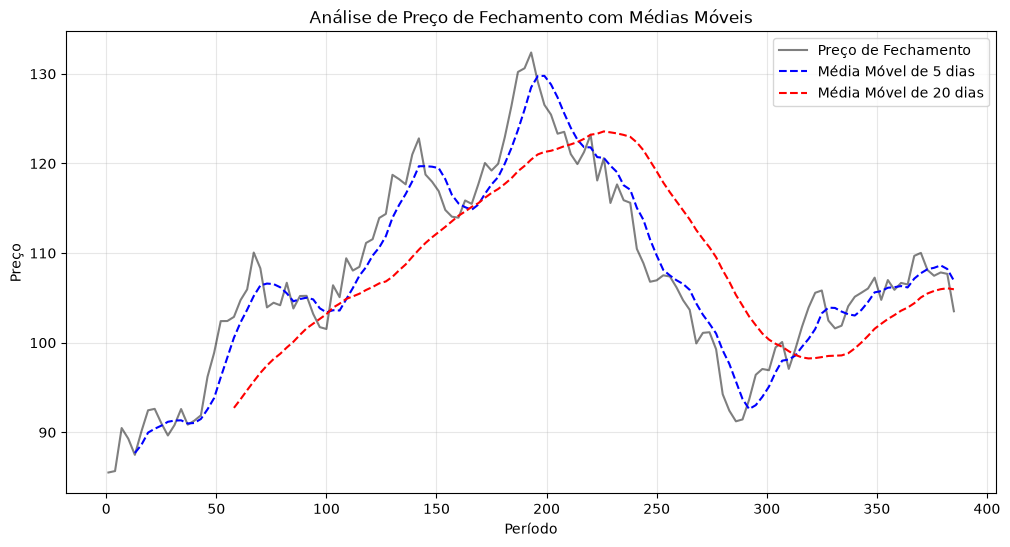

In [8]:
#display(vale)

plt.figure(figsize=(12, 6))

plt.plot(
    vale["Preco_Fechamento"],
    label="Preço de Fechamento",
    color="black",
    alpha=0.5
)
plt.plot(
    vale["Media_Movel_05"],
    label="Média Móvel de 5 dias",
    color="blue",
    linestyle="--"
)
plt.plot(
    vale["Media_Movel_20"],
    label="Média Móvel de 20 dias",
    color="red",
    linestyle="--"
)
plt.title("Análise de Preço de Fechamento com Médias Móveis")
plt.xlabel("Período")
plt.ylabel("Preço")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

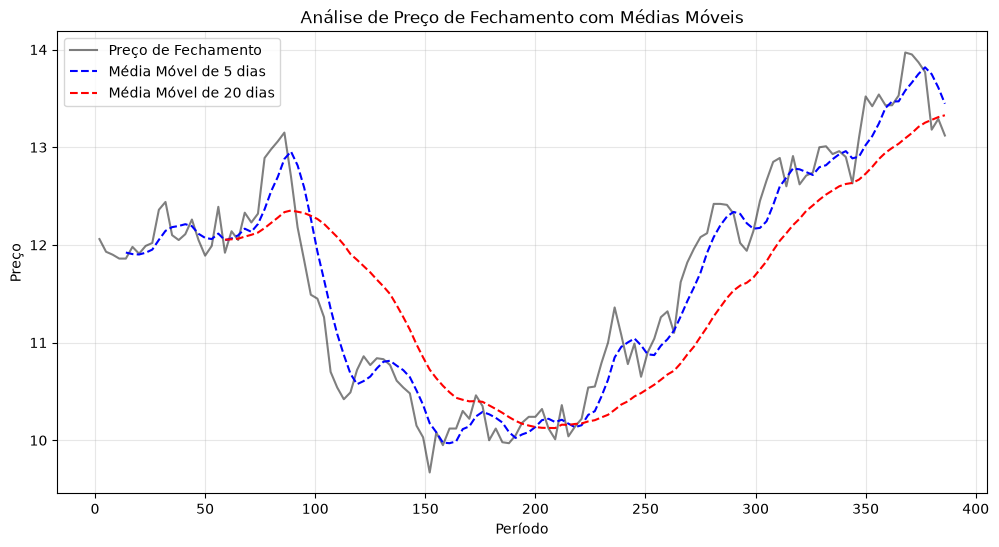

In [9]:
#display(vvar)

plt.figure(figsize=(12, 6))

plt.plot(
    vvar["Preco_Fechamento"],
    label="Preço de Fechamento",
    color="black",
    alpha=0.5
)
plt.plot(
    vvar["Media_Movel_05"],
    label="Média Móvel de 5 dias",
    color="blue",
    linestyle="--"
)
plt.plot(
    vvar["Media_Movel_20"],
    label="Média Móvel de 20 dias",
    color="red",
    linestyle="--"
)
plt.title("Análise de Preço de Fechamento com Médias Móveis")
plt.xlabel("Período")
plt.ylabel("Preço")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

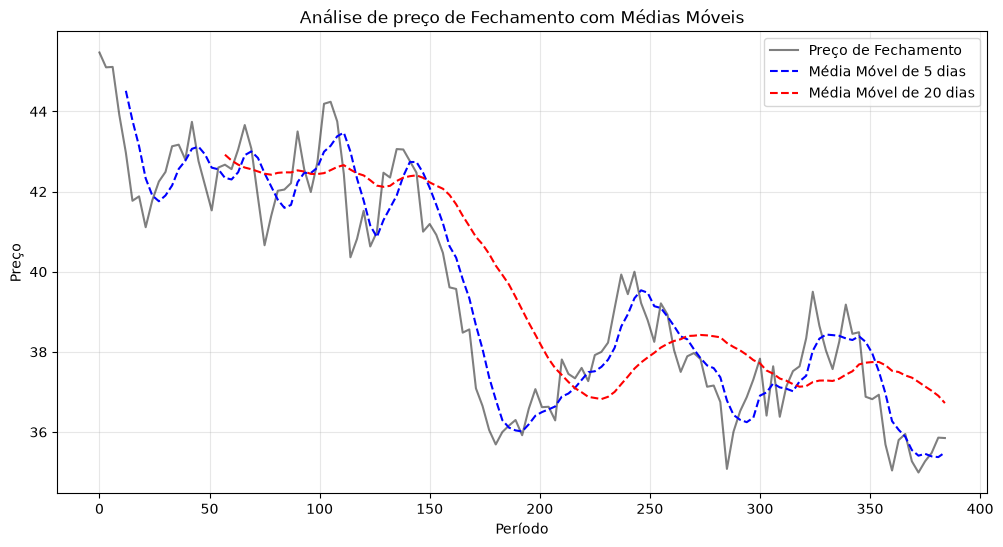

In [10]:
#display(tech)

plt.figure(figsize=(12, 6))

plt.plot(
    tech["Preco_Fechamento"],
    label="Preço de Fechamento",
    color="black",
    alpha=0.5
)
plt.plot(
    tech["Media_Movel_05"],
    label="Média Móvel de 5 dias",
    color="blue",
    linestyle="--"
)
plt.plot(
    tech["Media_Movel_20"],
    label="Média Móvel de 20 dias",
    color="red",
    linestyle="--"
)
plt.title("Análise de preço de Fechamento com Médias Móveis")
plt.xlabel("Período")
plt.ylabel("Preço")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

**Pergunta**: No último dia disponível no dataset (2026-06-30), para quais ativos a MM5 estava maior que a MM20?

In [52]:
alta = df_acoes[(df_acoes["Data"] == "2026-06-30") & (df_acoes["Media_Movel_05"] > df_acoes["Media_Movel_20"])]
display(alta)

,Data,Ticker,Preco_Abertura,Preco_Maxima,Preco_Minima,Preco_Fechamento,Volume_Milhoes,Spread_Percentual,Media_Movel_05,Media_Movel_20
385,2026-06-30,VALE4,102.84,104.27,102.62,103.51,103.41,1.607874,106.922,105.9610
386,2026-06-30,VVAR3,13.06,13.35,12.96,13.12,28.29,3.009259,13.446,13.3275


3. **Liquidez de Mercado** (Volume Financeiro)

Fundos de investimento grandes não podem comprar ações com pouca liquidez (baixo volume de negociação), pois têm dificuldade para sair da posição depois.

**Sua tarefa**: Descubra o volume total acumulado (soma) negociado por cada ativo no semestre.

In [12]:
volume_total = df_acoes.groupby("Ticker")["Volume_Milhoes"].sum()

**Pergunta**: Qual foi o ativo menos líquido (menor volume acumulado) e qual a porcentagem de participação dele no volume total do mercado simulado?

In [13]:
menor_volume = volume_total.min()
id_menor_volume = volume_total.idxmin()
print(f"O ativo com menor volume acumulado foi {id_menor_volume} com R${menor_volume} milhões")

O ativo com menor volume acumulado foi VVAR3 com R$7253.51 milhões


4. **Retorno Acumulado do Período**

O gestor quer saber quem entregou o maior lucro de ponta a ponta no semestre.

**Sua tarefa**: Descubra o preço de fechamento do primeiro dia disponível de cada ativo e o preço de fechamento do último dia disponível de cada ativo. Calcule o retorno percentual:

In [38]:
retorno = df_acoes.groupby("Ticker").apply(lambda x: ((x["Preco_Fechamento"].iloc[-1] - x["Preco_Abertura"].iloc[0]) / x["Preco_Abertura"].iloc[0]) * 100).reset_index(name="Retorno")
display(retorno)

,Ticker,Retorno
0,TECH3,-20.545213
1,VALE4,20.725449
2,VVAR3,8.519438


**Pergunta**: Qual ativo teve a melhor performance e qual foi o seu retorno percentual?

In [50]:
maior_retorno = retorno.max()
print(f"O ativo com a melhor performance foi {maior_retorno.iloc[0]} com {maior_retorno.iloc[-1]:.2f}%")

O ativo com a melhor performance foi VVAR3 com 20.73%


5. **Filtragem Avançada** (Dias de Stress)

Dias onde o mercado cai forte com muito volume negociado são chamados de "Dias de Stress" ou Sell-off.

**Sua tarefa**: Primeiro, crie uma coluna chamada Retorno_Diario que calcula a variação percentual do preço de fechamento de hoje em relação ao preço de fechamento do dia anterior (use .pct_change() por ativo).

In [56]:
df_acoes["Retorno_Diario"] = df_acoes.groupby("Ticker")["Preco_Fechamento"].pct_change() * 100

**Pergunta**: Quantas vezes o ativo TECH3 teve um dia de queda (Retorno Diário < 0) em que o Volume Financeiro do dia foi maior que a média de volume do próprio TECH3 em todo o período?

In [62]:
tech = df_acoes[df_acoes["Ticker"] == "TECH3"]
media = tech["Volume_Milhoes"].mean()
quant = len(tech[(tech["Retorno_Diario"] < 0) & (tech["Volume_Milhoes"] > media)])
print(f"Isso aconteceu {quant} vezes")

Isso aconteceu 27 vezes
